In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

In [8]:
# read the csv into a DataFrame
df = pd.read_csv("Lecture_9_Data/hour.csv", parse_dates=['dteday'])
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [9]:
df.dtypes

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

In [10]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### Data exploration

In [11]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


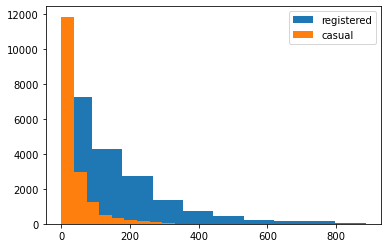

In [24]:
plt.hist(df['registered'])
plt.hist(df['casual'])
plt.legend(['registered', 'casual'])
plt.show()

In [26]:
sum(df['registered'])

2672662

In [27]:
sum(df['casual'])

620017

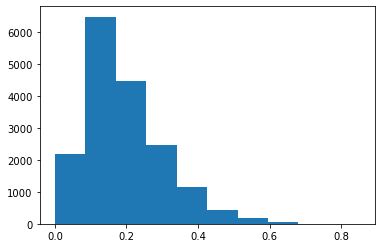

In [29]:
plt.hist(df['windspeed'])
plt.show()

In [33]:
df_groupby_hour_mean = df.groupby('hr').mean()[['cnt']]
df_groupby_hour_mean

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


<BarContainer object of 24 artists>

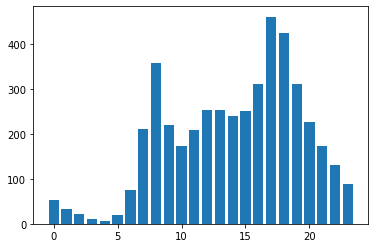

In [36]:
plt.bar(df_groupby_hour_mean.index, df_groupby_hour_mean['cnt'])

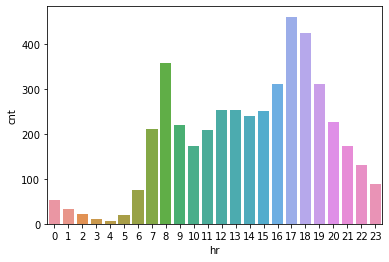

In [37]:
sns.barplot(df_groupby_hour_mean.index, df_groupby_hour_mean['cnt'])

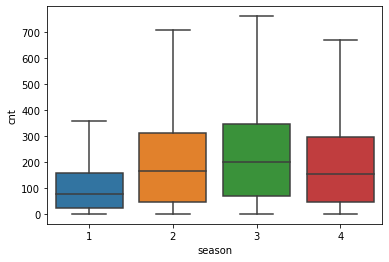

In [39]:
sns.boxplot(df['season'], df['cnt'], showfliers = False)

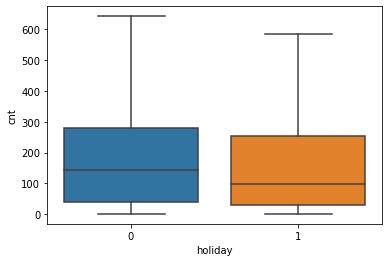

In [40]:
sns.boxplot(df['holiday'], df['cnt'], showfliers = False)

In [41]:
from scipy.stats import mannwhitneyu

In [43]:
non_holiday_df = df[df['holiday'] == 0]
holiday_df = df[df['holiday'] == 1]

In [44]:
mannwhitneyu(non_holiday_df['cnt'], holiday_df['cnt'])

MannwhitneyuResult(statistic=3789427.5, pvalue=4.964991884124428e-05)

In [45]:
print(non_holiday_df['cnt'].median())
print(holiday_df['cnt'].median())

144.0
97.0


(array([  78.,  786., 2342., 2631., 3047., 3216., 3942., 1044.,  279.,
          14.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 10 Patch objects>)

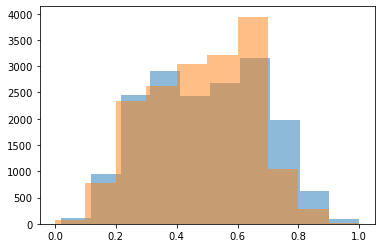

In [47]:
plt.hist(df['temp'], alpha = 0.5)
plt.hist(df['atemp'], alpha = 0.5)

(array([6.1000e+02, 1.2971e+04, 3.7060e+03, 6.8000e+01, 0.0000e+00,
        0.0000e+00, 6.0000e+00, 7.0000e+00, 4.0000e+00, 7.0000e+00]),
 array([-0.1012 , -0.02932,  0.04256,  0.11444,  0.18632,  0.2582 ,
         0.33008,  0.40196,  0.47384,  0.54572,  0.6176 ]),
 <a list of 10 Patch objects>)

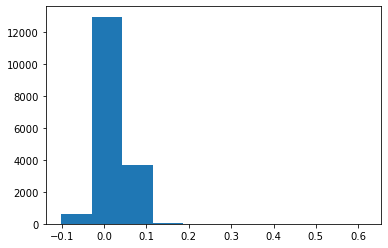

In [48]:
plt.hist(df['temp'] - df['atemp'])

In [49]:
# 705pm
# think of 1 or 2 more things to investigate

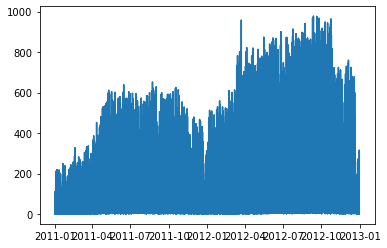

In [52]:
plt.plot(df['dteday'], df['cnt'])

In [65]:
df_sample = df.set_index('dteday')
df_m_resample = df_sample.resample('M').sum()

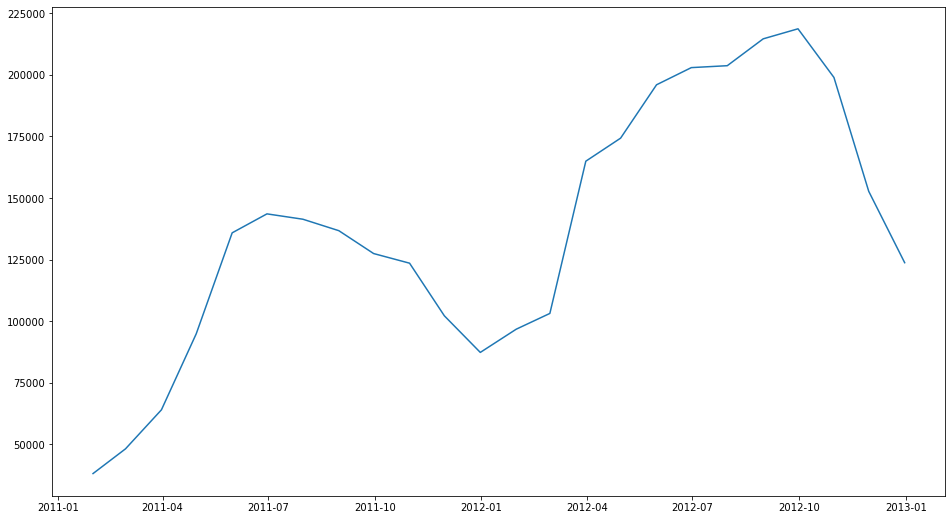

In [66]:
plt.figure(figsize = (16, 9))
plt.plot(df_m_resample['cnt'])

### Data preparation

In [115]:
df['year'] = df['dteday'].dt.year
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16,2011
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40,2011
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32,2011
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13,2011
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119,2012
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89,2012
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90,2012
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61,2012


In [116]:
X = df.drop(['instant', 'dteday', 'casual', 'registered', 'cnt'], axis = 1)
y = df['cnt']

In [117]:
first_80 = round(0.8 * len(X))

In [118]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

X_train = X[:first_80]
X_test = X[first_80:]

y_train = y[:first_80]
y_test = y[first_80:]

In [119]:
dummy = DummyRegressor()
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

232.60837481037086


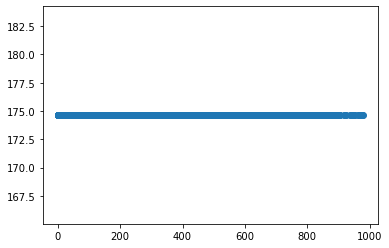

In [120]:
print(np.sqrt(mean_squared_error(y_test, dummy_pred)))
plt.scatter(y_test, dummy_pred)

In [121]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

183.27604724447357


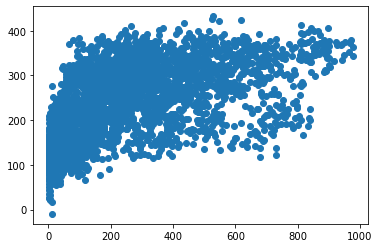

In [122]:
print(np.sqrt(mean_squared_error(y_test, lr_pred)))
plt.scatter(y_test, lr_pred)

In [123]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

85.70485648550716


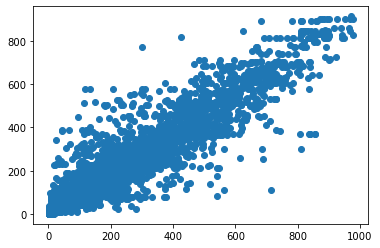

In [124]:
print(np.sqrt(mean_squared_error(y_test, dt_pred)))
plt.scatter(y_test, dt_pred)

In [125]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

70.01872287195224


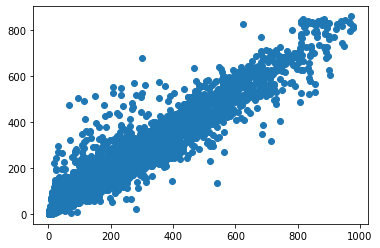

In [126]:
print(np.sqrt(mean_squared_error(y_test, rf_pred)))
plt.scatter(y_test, rf_pred)

In [127]:
# create a new column called prediction
# first 80% -> original cnt
# last 20% -> prediction
prediction_column = list(y_train) + list(rf_pred)

df_sample['predict'] = prediction_column
df_sample

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,predict
dteday,,,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16,16.00
2011-01-01,2,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40,40.00
2011-01-01,3,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32,32.00
2011-01-01,4,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13,13.00
2011-01-01,5,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31,17375,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119,223.32
2012-12-31,17376,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89,177.65
2012-12-31,17377,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90,116.71


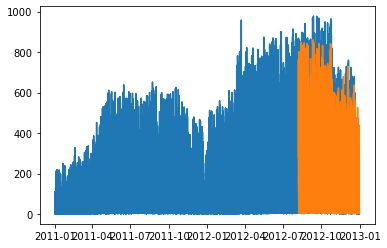

In [128]:
plt.plot(df_sample['cnt'])
plt.plot(df_sample['predict'][first_80:])

In [129]:
df_m_resample = df_sample.resample('M').sum()
df_m_resample

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,predict
dteday,,,,,,,,,,,,,,,,,
2011-01-31,237016,688,0,688,8168,24,2018,429,1014,135.82,140.1854,394.95,135.8697,3073,35116,38189,38189.000000
2011-02-28,657437,649,0,1298,7649,24,1957,436,944,184.30,185.4385,363.25,148.9139,6242,41973,48215,48215.000000
2011-03-31,1242825,990,0,2190,8506,0,2202,541,1135,241.80,237.1618,416.14,169.5245,12826,51219,64045,64045.000000
2011-04-30,1745013,1438,0,2876,8277,24,2279,479,1120,338.66,328.3127,480.45,175.5113,22346,72524,94870,94870.000000
2011-05-31,2349924,1488,0,3720,8556,24,2088,504,1065,429.46,409.8053,530.74,134.8680,31050,104771,135821,135821.000000
2011-06-30,2801160,1680,0,4320,8280,0,2184,528,942,499.02,465.5228,427.14,128.3007,30612,112900,143512,143512.000000
2011-07-31,3439140,2232,0,5208,8556,24,2280,480,866,564.38,528.7312,438.71,127.7206,36452,104889,141341,141341.000000
2011-08-31,3918160,2193,0,5848,8412,0,2124,552,946,515.76,479.2798,457.33,137.5098,28842,107849,136691,136691.000000
2011-09-30,4362228,2343,0,6453,8274,24,2225,501,1192,439.46,407.6798,562.00,109.5268,26545,100873,127418,127418.000000


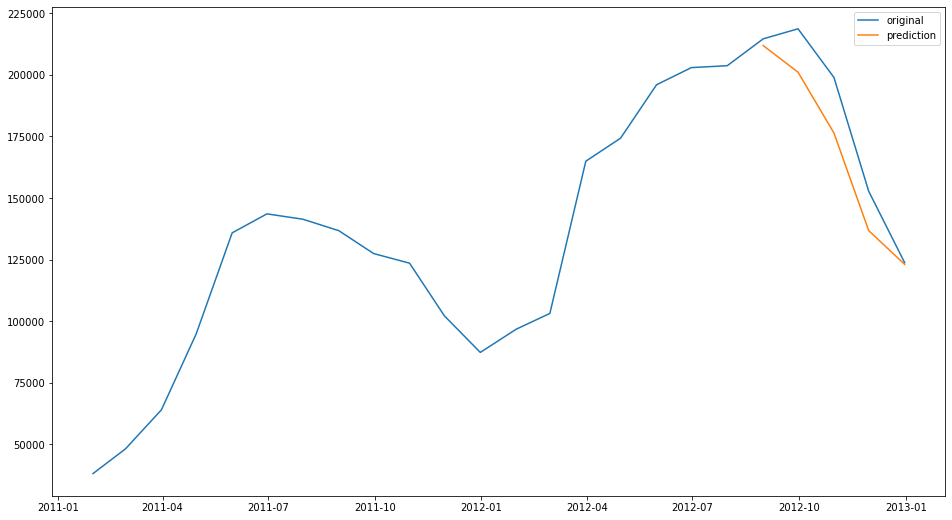

In [130]:
plt.figure(figsize = (16, 9))
plt.plot(df_m_resample['cnt'])
plt.plot(df_m_resample['predict'][-5:])
plt.legend(['original', 'prediction'])